# Seaborn 01

- We will use the full data set so that the plots look meaningful. 

### Setup

In [29]:
import pandas as pd
import seaborn as sns

##### Get the prepared data and look at the beginning and end

In [30]:
mortality_data = pd.read_pickle('mortality_prepped.pkl')
mortality_data.head()

,Year,AgeGroup,DeathRate,MeanCentered
0,1900,01-04 Years,1983.8,1790.87584
1,1901,01-04 Years,1695.0,1502.07584
2,1902,01-04 Years,1655.7,1462.77584
3,1903,01-04 Years,1542.1,1349.17584
4,1904,01-04 Years,1591.5,1398.57584


In [31]:
mortality_data.tail()

,Year,AgeGroup,DeathRate,MeanCentered
471,2014,15-19 Years,45.5,-147.42416
472,2015,15-19 Years,48.3,-144.62416
473,2016,15-19 Years,51.2,-141.72416
474,2017,15-19 Years,51.5,-141.42416
475,2018,15-19 Years,49.2,-143.72416


## Types of plots

### Relational plots (replot)

#### General Relational Plot
-replot()

#### Specific Relational Plot
-scatterplot()
- lineplot()

#### What's the difference
- Scatter plots (scatterplot). Scatter plots are best used to show the relationships between numeric variables
- Line plots (lineplot). Line plots are best used to identify trends in data and show change over time.

##### When to general vs. specific?
- Use relplot (general) when you need:
    - Faceting (subsets of data with a subplot)
    - Multiple plots in one figure
    - High-level layout control

- Use scatterplot or lineplot (specific) when you need:

- One simple plot
    - Full control over axes-level customization
    - Integration into a Matplotlib subplot
 
### Catgegorial Plots


### Distribution Plots


##### General Relational Plot
- Can create subplots
- Return Grid object that contains axes of subplots
- "kind" parameter required in general plot
- "hue" represents categories
- Plots created by the specific method:
  - Wider and shorter
  - Have a border with legend placed in the border

##### INFO:  The warning about "figure layout" can be ignored.

/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


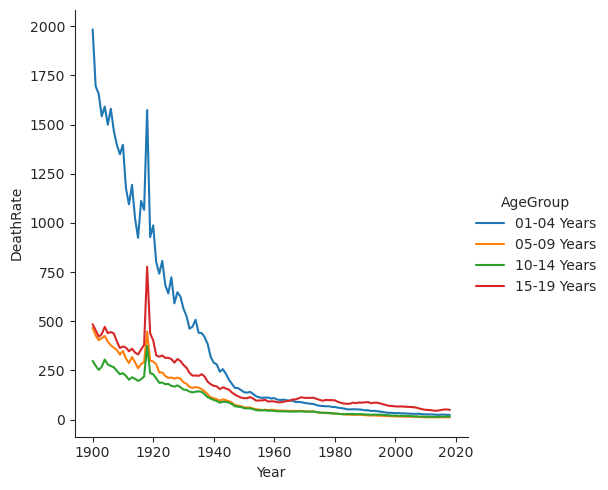

In [32]:
sns.relplot(data=mortality_data, kind='line',
            x='Year', y='DeathRate', hue='AgeGroup')

<Axes: xlabel='Year', ylabel='DeathRate'>

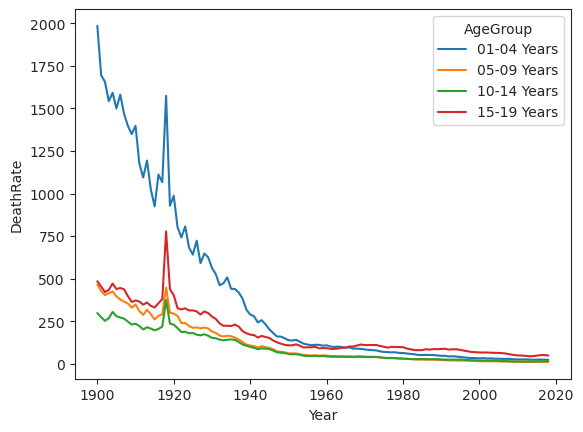

In [33]:
sns.lineplot(data=mortality_data, 
             x='Year', y='DeathRate', hue='AgeGroup')

## Basic parameters

The basic Seaborn parameters are usually all that you need for the plots you develop for your own analyses (see book for full table of parameters).

- data: DataFrame
- kind: Type of plot
- x,y:  columns for axis
- hue:  categories


/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


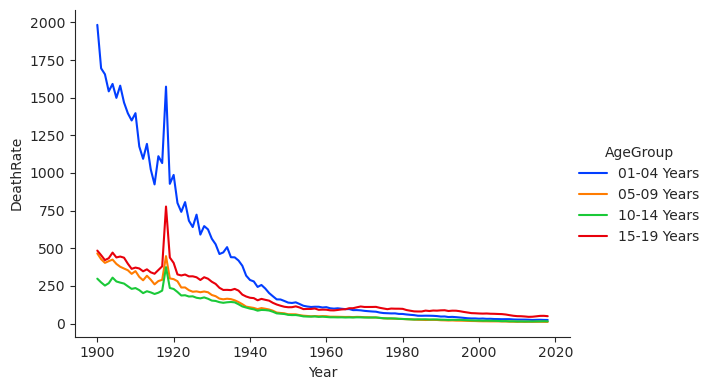

In [34]:
sns.relplot(data=mortality_data, kind='line',
x='Year', y='DeathRate', hue='AgeGroup', palette='bright', height=4, aspect=1.5)


### Subplots

The basic Seaborn parameters are usually all that you need for the plots you develop
for your own analyses.
col: The column that determines the subplots
col_wrap: the number of subplots in each row

/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


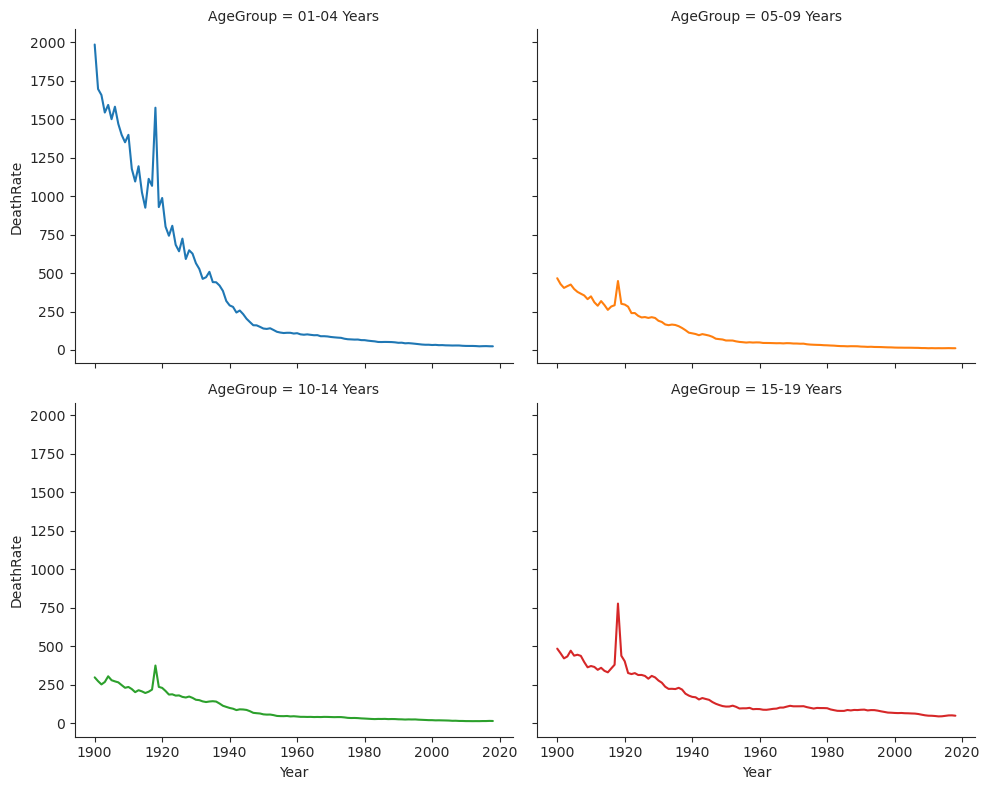

In [35]:
sns.relplot(data=mortality_data, 
            kind='line', x='Year', y='DeathRate', hue='AgeGroup', 
            height=4, aspect=1.25, 
            col='AgeGroup', col_wrap=2, legend=False)

## Set the title and the x and y labels¶

## Set the ticks, x limits, and y limits
- xticks and yticks parameters to set specific tick values for your plots.
- xlim and ylim parameters to limit the data that’s presented in your plots.
- Example
    - Display from 1910 to 1930 and show ticks every two years.
    - Since the range will be smaller, set the top value of the x axis at 1750 (not 2000)


/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


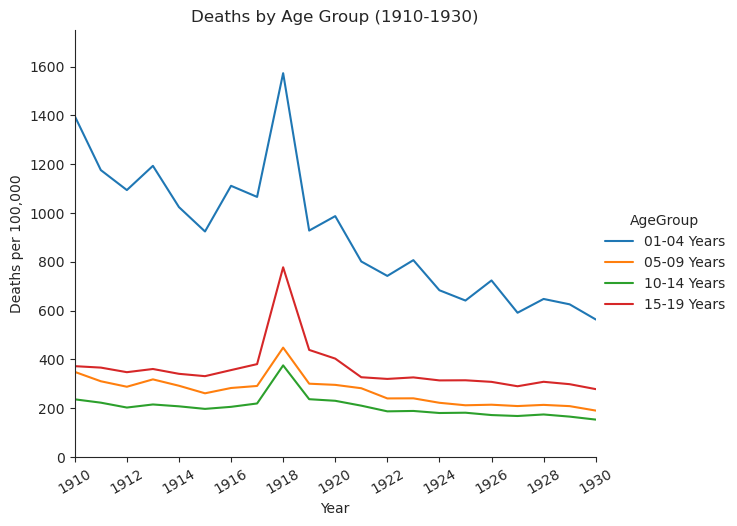

In [36]:
g = sns.relplot(data=mortality_data, kind='line',
    x='Year', y='DeathRate', hue='AgeGroup', aspect=1.25)
for ax in g.axes.flat:
    ax.set(title='Deaths by Age Group (1910-1930)', ylabel='Deaths per 100,000', 
        xticks=[x for x in range(1910, 1931, 2)], 
        xlim=(1910,1930), ylim=(0,1750)),
    ax.tick_params('x', labelrotation=30)

### Repeat with a line plot
- Notice the differences with:
    - Border
    - Kind
    - Border around categories

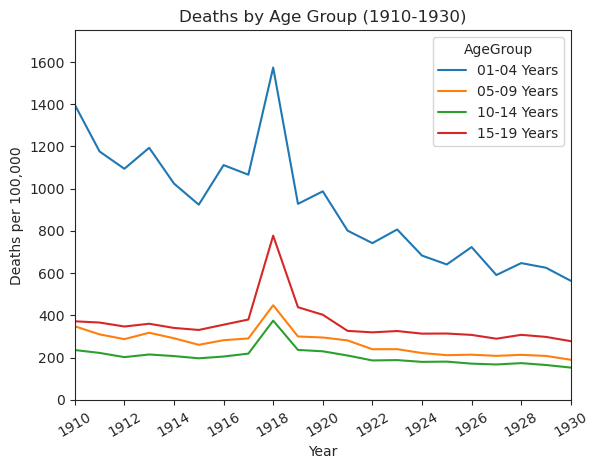

In [37]:
ax = sns.lineplot(data=mortality_data,
     x='Year', y='DeathRate', hue='AgeGroup')
ax.set(title='Deaths by Age Group (1910-1930)', 
      ylabel='Deaths per 100,000', 
      xticks=[x for x in range(1910,1931,2)], 
      xlim=(1910,1930), ylim=(0,1750))
ax.tick_params('x', labelrotation=30)

## Experiment wiht different background styles
- The default style is ticks, which has a plain white background and tick marks for each of the ticks on the axes.
- The white style provides a plain white background but without the tick marks. The dark style is the same as the white style but the background is dark rather than white.
- And the whitegrid and darkgrid styles add grid lines to each tick for the dark and white styles.

/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


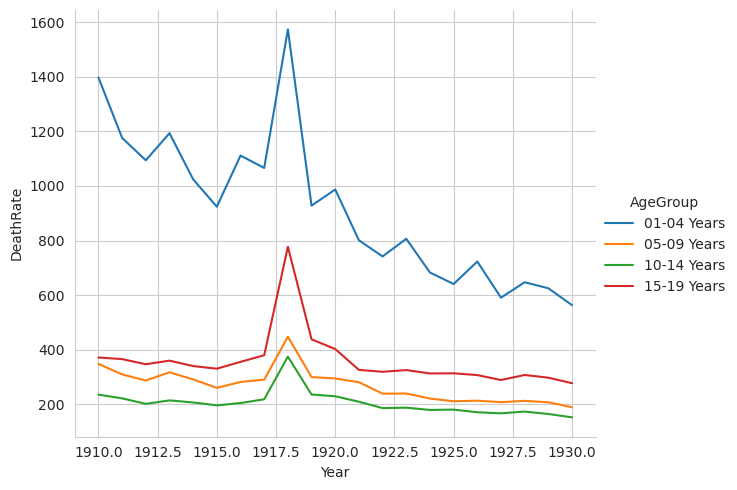

In [38]:
sns.set_style('whitegrid')
sns.relplot(data=mortality_data.query('Year >= 1910 and Year <= 1930'),
    kind='line', x='Year', y='DeathRate', hue='AgeGroup', aspect=1.25)

/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


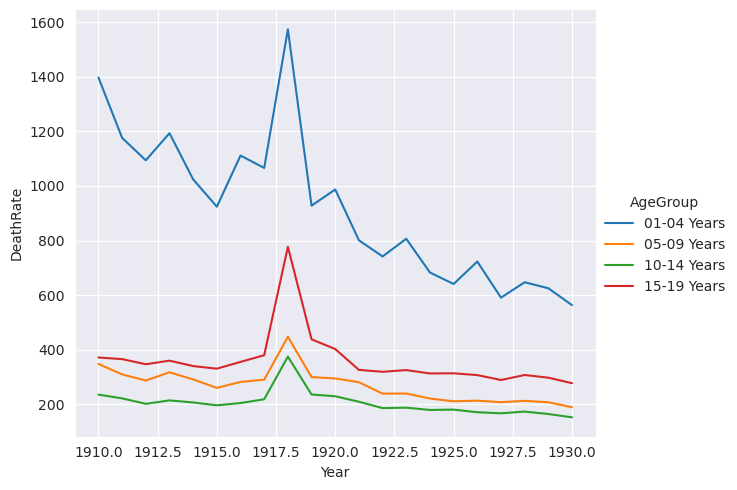

In [39]:
sns.set_style('darkgrid')
sns.relplot(data=mortality_data.query('Year >= 1910 and Year <= 1930'),
    kind='line', x='Year', y='DeathRate', hue='AgeGroup', aspect=1.25)

## Working with Subplots

##### First look at the the first part of the plot

/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


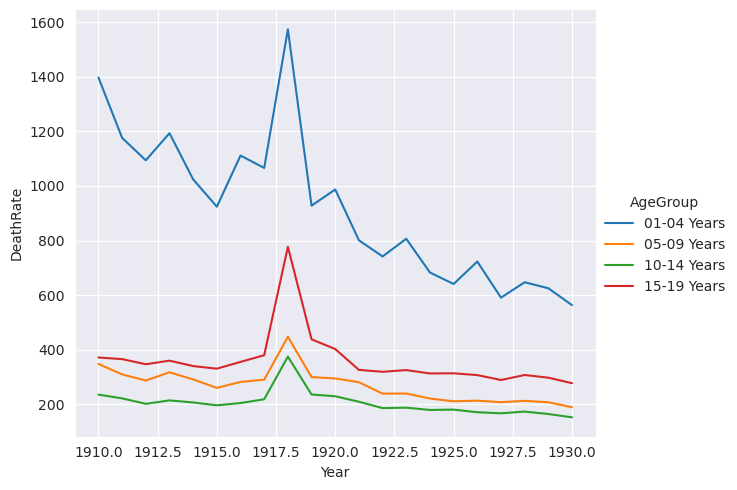

In [40]:
sns.set_style('darkgrid')
sns.relplot(data=mortality_data.query('Year >= 1910 and Year <= 1930'),
    kind='line', x='Year', y='DeathRate', hue='AgeGroup', aspect=1.25)

##### Then add the col and the col_wrap to make a subplot

/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


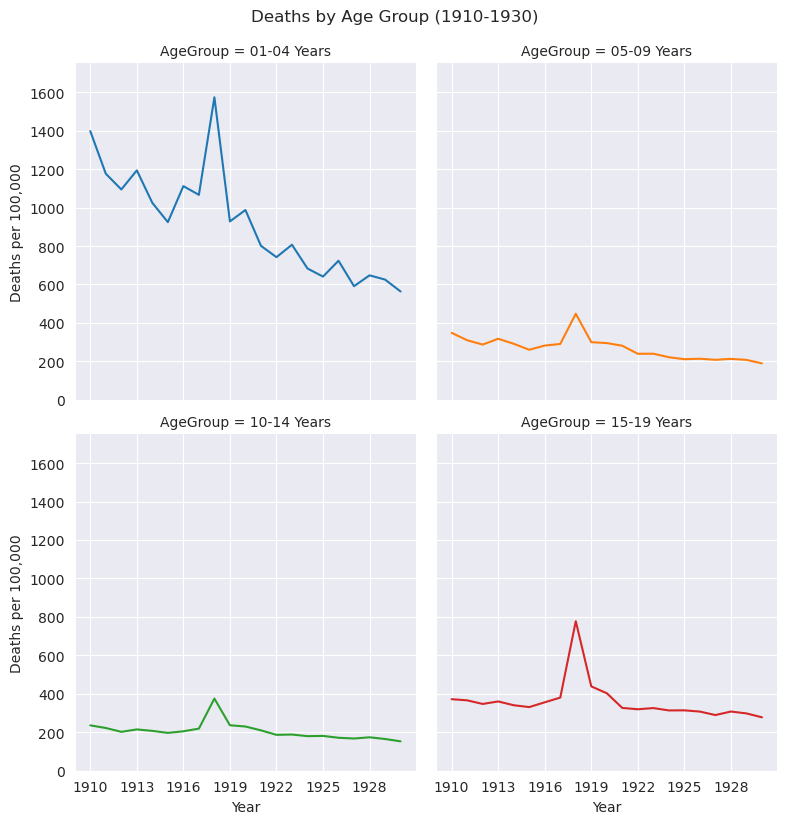

In [41]:
g = sns.relplot(data=mortality_data.query('Year >= 1910 and Year <= 1930'),
    kind='line', x='Year', y='DeathRate', hue='AgeGroup', legend=False,
    col='AgeGroup', col_wrap=2, height=4)
g.fig.suptitle('Deaths by Age Group (1910-1930)', y=1.025)
g.set(ylabel='Deaths per 100,000', 
      xticks=[x for x in range(1910,1931,3)], 
      ylim=(0,1750))

##### Then add the "for" loop which adds more years in the ticks

/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


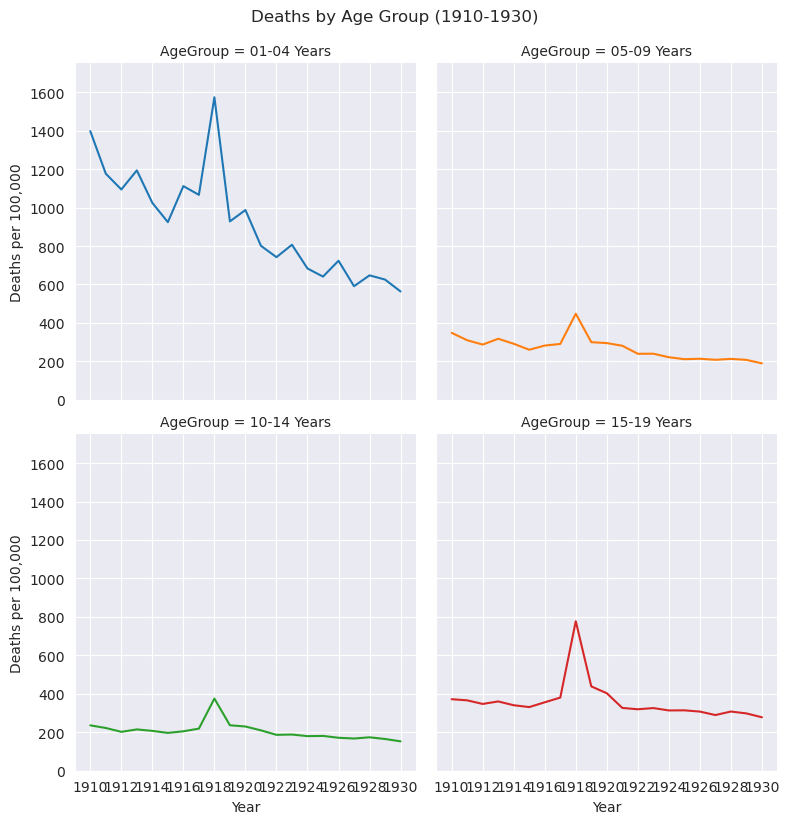

In [42]:

g = sns.relplot(data=mortality_data.query('Year >= 1910 and Year <= 1930'), kind='line', x='Year', y='DeathRate', hue='AgeGroup', legend=False, col='AgeGroup', col_wrap=2, height=4)
g.fig.suptitle('Deaths by Age Group (1910-1930)', y=1.025)
for ax in g.axes.flat:
    ax.set(ylabel='Deaths per 100,000', 
    xticks=[x for x in range(1910,1931,2)],
    ylim=(0,1750))

## Save a plot to a file
- Using general and specific
- Assign FacetGrid object to var g
- get_figure() gets the line plot from the Axes object
- Adjust as necessary
- NOTE:  savefig(filename) is a method that is part of the FacetGrid object or a Figure object
- get_figure is a method that is part of the Axes object

/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


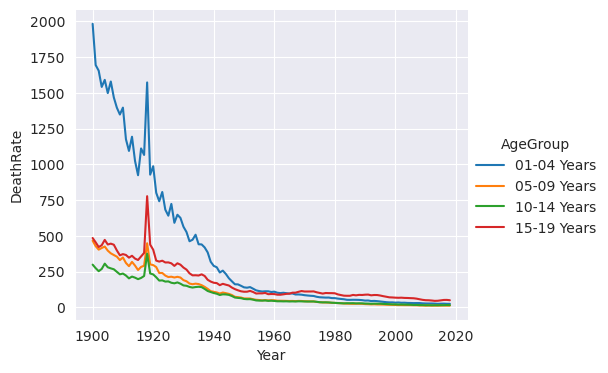

In [43]:
g = sns.relplot(data=mortality_data, kind='line',
                x='Year', y='DeathRate', hue='AgeGroup')
g.fig.subplots_adjust(bottom=0.35)  # adjust the bottom to fix the y labels
g.savefig('figures/mylineChart-01.png')
g.savefig('figures/mylineChart-01.svg')
g.savefig('figures/mylineChart-01.pdf')

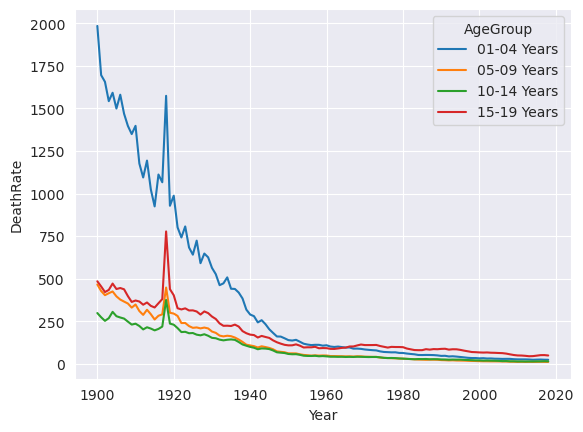

In [44]:
ax = sns.lineplot(data=mortality_data, 
                  x='Year', y='DeathRate', hue='AgeGroup')
ax.get_figure().savefig('figures/mylineChart-02.png')
ax.get_figure().savefig('figures/mylineChart-02.svg')
ax.get_figure().savefig('figures/mylineChart-02.pdf')

## Relational Plots

### Details on Line Plots

- **Pros:**
  - Excellent for showing trends over time.
  - Makes it easy to compare changes across age groups.
  - Clean and familiar for time series.
- **Cons:**
  - Can become cluttered with too many age groups.
  - Doesn’t show variation within a year.

/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


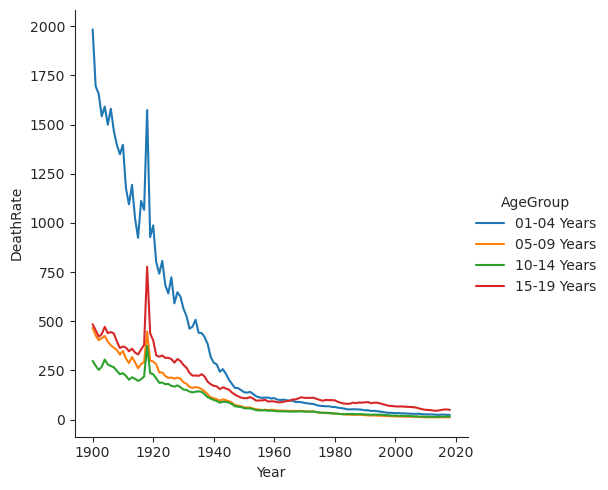

In [45]:
sns.set_style('ticks')
sns.relplot(data=mortality_data, kind='line', x='Year', y='DeathRate', 
            hue='AgeGroup')

- Don't code the hue parameter
    - Single line plots the average death rate for all 4 age groups
- The default confidence interval is 95% (error bar)
- The error bar is the shaded areas above and below the line.
- You can change the error bar to be the standard deviation or none. 

##### Confidence Interval
- Represents precision of the sample mean
- A range of values that is likely to contain the true population parameter
- Based on my sample the value is likely to fall between . . . 
- The wider the interval the more uncertain the estimate

##### Confidence Interval
- Represents variability in the data.  How spread out is the data?


/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


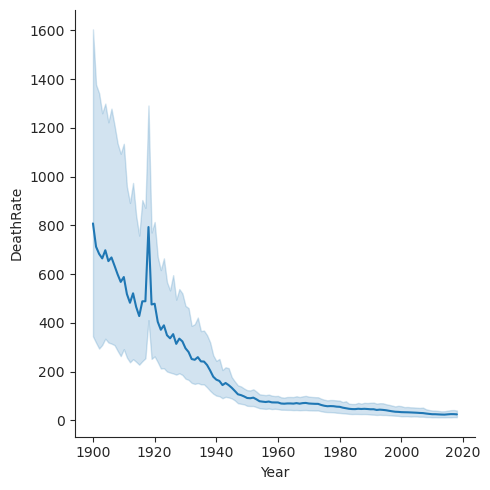

In [46]:
sns.relplot(data=mortality_data, kind='line', x='Year', y='DeathRate')

/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


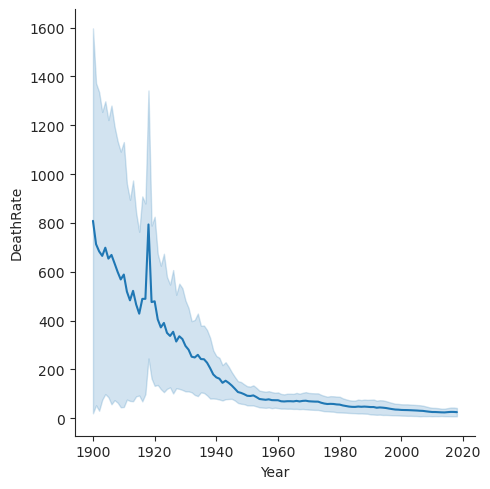

In [47]:
sns.relplot(data=mortality_data, kind='line', x='Year', y='DeathRate', errorbar='sd')

### Scatter plots
- Line plot is more about trends
- Scatter plot helps see clustering or outliers

/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


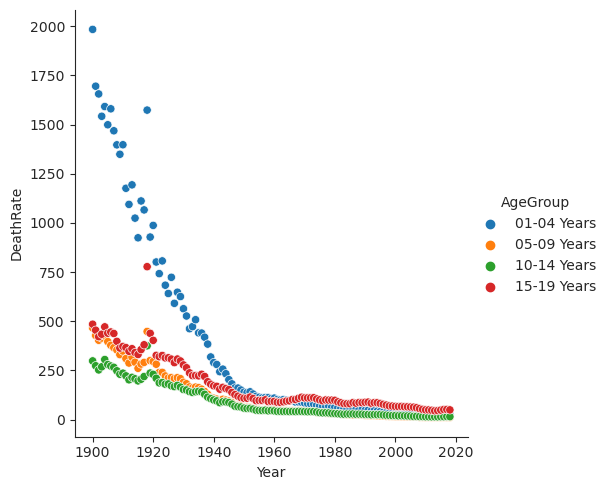

In [48]:
sns.relplot(data=mortality_data, kind='scatter', x='Year', y='DeathRate', 
            hue='AgeGroup')

## Categorical Plots
1. barplot()
2. boxplot()
3. stripplot()
4. swarmplot()
5. pointplot()
6. boxenplot()
7. violinplot()
8. countplot()

### Bar plots
- A bar plot is used when you want to compare quantities across different categories
- One of the most common and effective ways to visualize categorical data.

- **Pros:**
  - Clear comparison of death rates at specific years.
  - Stacked bars can show total and parts (age groups).
- **Cons:**
  - Not ideal for visualizing long time series.
  - Hard to interpret trends across years.

/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


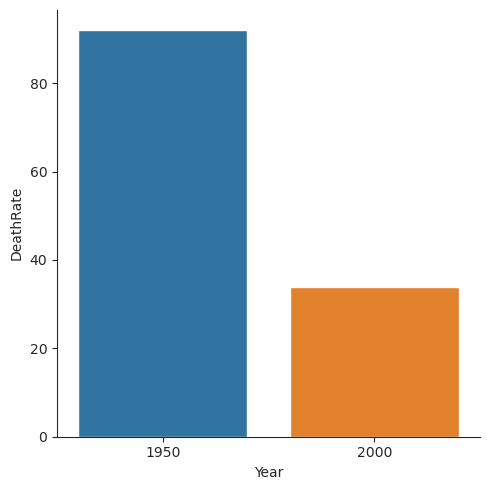

In [49]:
sns.catplot(data=mortality_data.query('Year in (1950,2000)'), 
            kind='bar', x='Year', y='DeathRate', errorbar=None)

/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


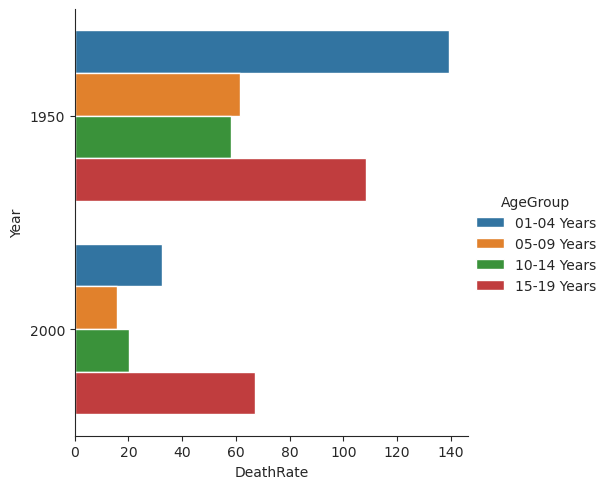

In [50]:
sns.catplot(data=mortality_data.query('Year in (1950,2000)'), 
            kind='bar', x='DeathRate', y='Year', hue='AgeGroup', orient='h')

### Box  plots
- The box in a box plot represents the first and third quartiles of the data that’s being plotted, and the horizontal line through the box represents the median.
- The whisker at the bottom of the box goes down to the minimum, and the whisker at the top goes up to the maximum.
- Any dots below the minimum or above the maximum whiskers represent outliers.
  
- **Pros:**
  - Great for summarizing distribution (median, quartiles, outliers) by year or age group.
  - Helps detect age groups with high variability in death rate.
- **Cons:**
  - Doesn’t show trends or exact values well.
  - Less intuitive for beginners.


/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


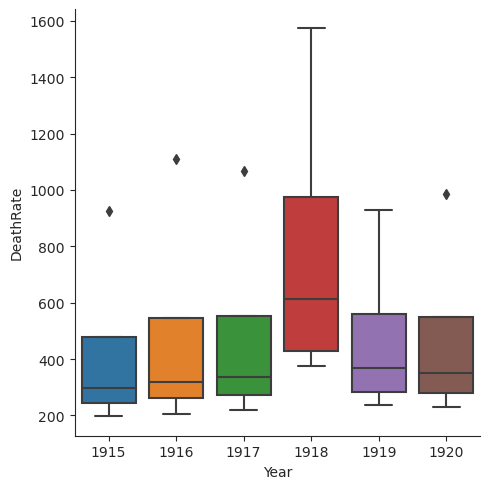

In [51]:
sns.catplot(data=mortality_data.query('Year >= 1915 and Year <= 1920'), 
            kind='box', x='Year', y='DeathRate')

### Histogram

- **Pros:**
  - Good for showing distribution of death rates (not trends).
  - Helps identify skewness and modality.
- **Cons:**
  - Not suitable for showing changes over time.
  - Doesn’t use the year axis meaningfully.

/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


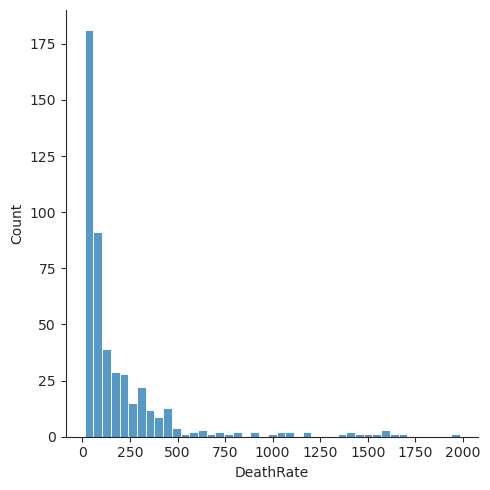

In [52]:
sns.displot(data=mortality_data, kind='hist', x='DeathRate')

###  KDE and ECDF plots

- **Pros:**
  - Smooth version of a histogram.
  - Helps compare death rate distributions between age groups.
- **Cons:**
  - Not time-based; like histograms, it ignores the year.
  - Smoothing may hide actual data characteristics.

/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


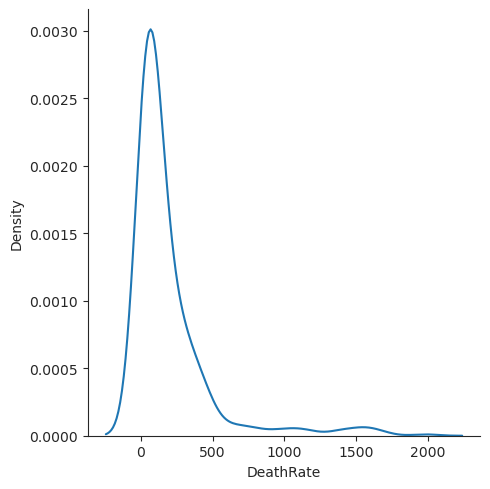

In [53]:
sns.displot(data=mortality_data, kind='kde', x='DeathRate')

### Enhanced distribution plots

/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


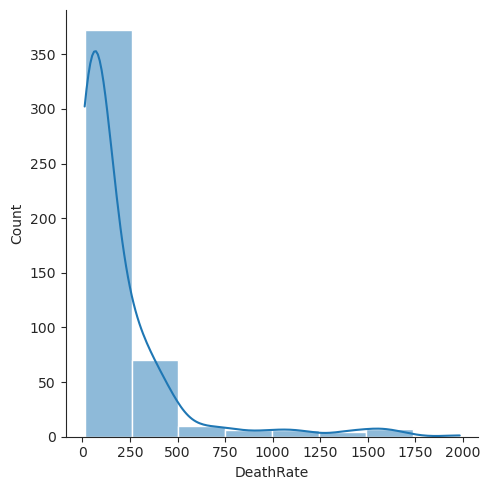

In [54]:
sns.displot(data=mortality_data, kind='hist', 
            x='DeathRate', kde=True, bins=8)

/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


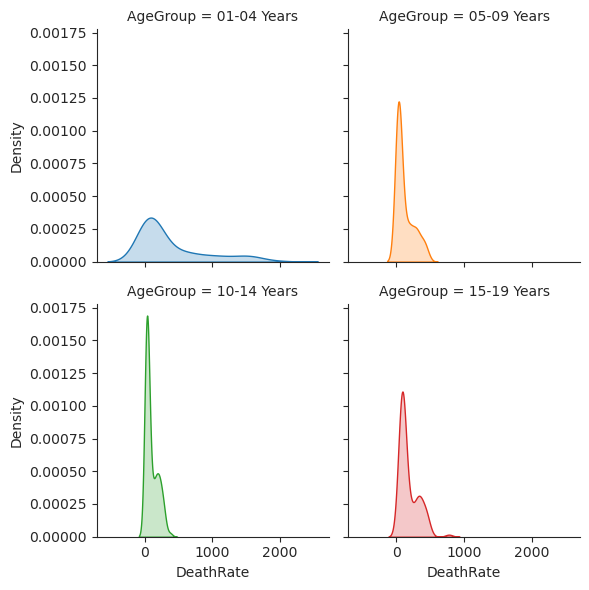

In [55]:
sns.displot(data=mortality_data, kind='kde', x='DeathRate', hue='AgeGroup', 
            fill=True, col='AgeGroup', col_wrap=2, height=3, legend=False)

### Annotate a plot

Text(1925, 1900, 'Spanish Flu Pandemic')

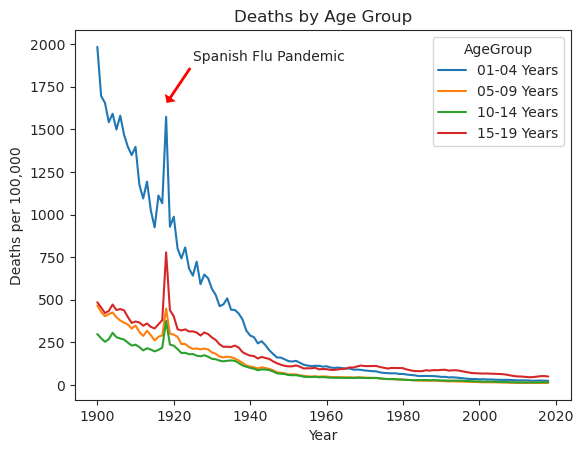

In [56]:
ax = sns.lineplot(data=mortality_data, 
                  x='Year', y='DeathRate', hue='AgeGroup')
ax.set_title('Deaths by Age Group')
ax.set_ylabel('Deaths per 100,000')
ax.annotate(text='Spanish Flu Pandemic', 
    xy=(1918, 1650), xytext=(1925, 1900), 
    arrowprops=dict(facecolor='red', width=3, headwidth=12, headlength=6))

## Set color pallette

/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


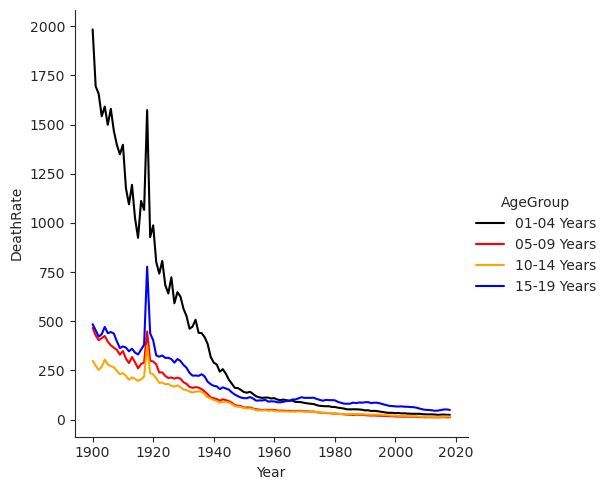

In [57]:
colors = ['black','red','orange','blue']
sns.set_palette(sns.color_palette(colors))
sns.relplot(data=mortality_data, kind='line',
            x='Year', y='DeathRate', hue='AgeGroup')

## Axes methods for enhancing subplots

/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


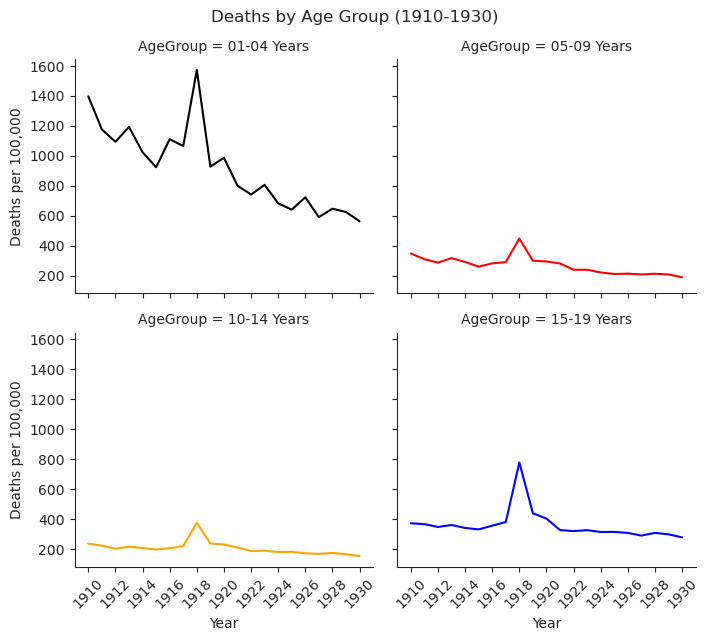

In [58]:
g = sns.relplot(
    data=mortality_data.query('Year >= 1910 and Year <= 1930'),
    kind='line', x='Year', y='DeathRate', hue='AgeGroup', legend=False,
    col='AgeGroup', col_wrap=2, height=3, aspect=1.2)
g.fig.suptitle('Deaths by Age Group (1910-1930)', y=1.025)
for ax in g.axes.flat:
    ax.set_ylabel('Deaths per 100,000')
    ax.set_xticks([x for x in range(1910, 1931, 2)])
    ax.tick_params('x', labelrotation=45)   

## Custom titles for subplots

/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


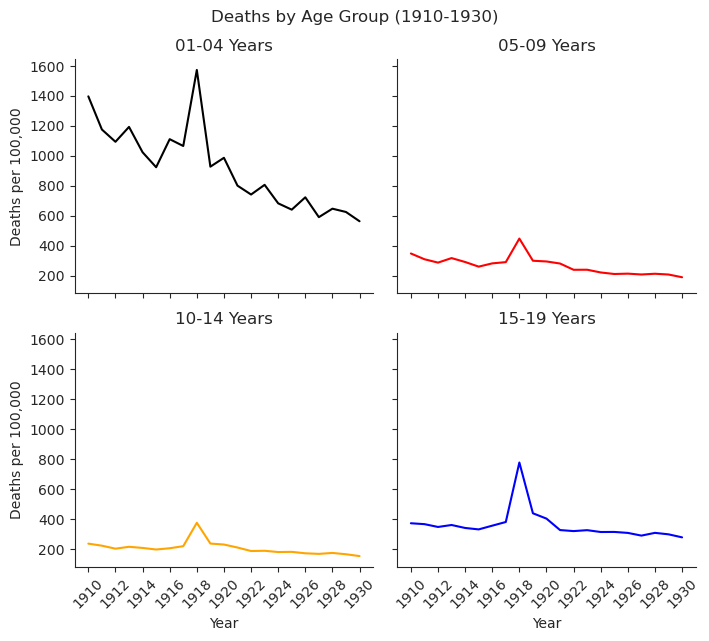

In [59]:
g = sns.relplot(
    data=mortality_data.query('Year >= 1910 and Year <= 1930'), 
    kind='line', x='Year', y='DeathRate', hue='AgeGroup', legend=False, 
    col='AgeGroup', col_wrap=2, height=3, aspect=1.2)
g.fig.suptitle('Deaths by Age Group (1910-1930)', y=1.025)
ageGroups = mortality_data['AgeGroup'].drop_duplicates().tolist()
for index, ax in enumerate(g.axes.flat):
    ax.set_title(ageGroups[index])
    ax.set_ylabel('Deaths per 100,000')
    ax.set_xticks([x for x in range(1910, 1931, 2)])
    ax.tick_params('x', labelrotation=45)

## Set the size for a specific plot

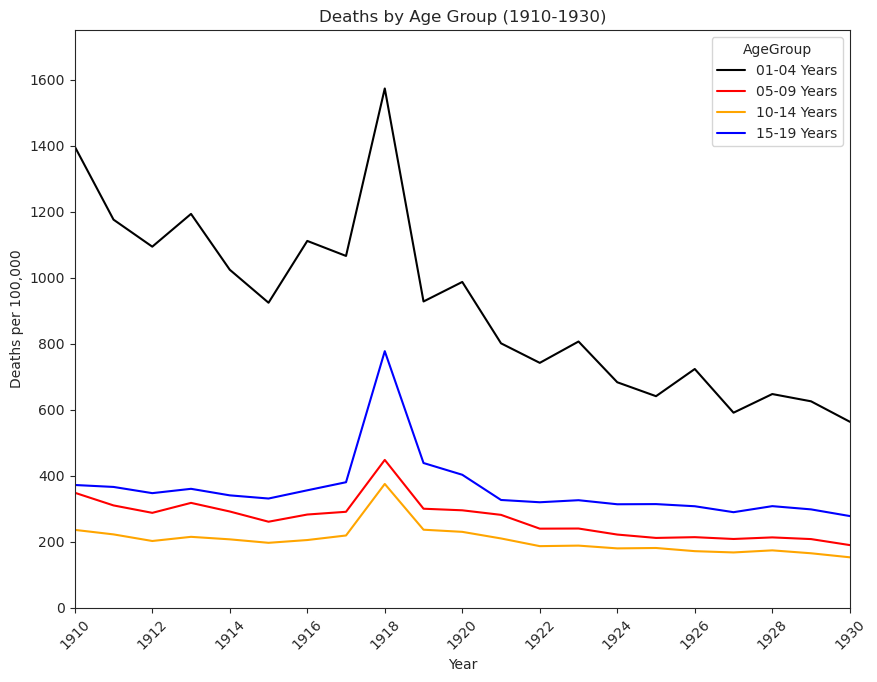

In [60]:
# import a Matplotlib module and set the figure size
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10,7.5)) 

# create the line plot
sns.lineplot(data=mortality_data, x='Year', y='DeathRate', hue='AgeGroup')

# use the ax and fig objects to enhance and save the plot
ax.set(title='Deaths by Age Group (1910-1930)', 
    ylabel='Deaths per 100,000', 
    xticks=[x for x in range(1910, 1931, 2)], 
    xlim=(1910,1930), ylim=(0,1750)),
ax.tick_params('x', labelrotation=45)
fig.savefig('deaths_by_age_group_line.png')